In [ ]:
# 1. Importing data from Excel
# ########################################################################## 

# %pip install seaborn

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sea
from IPython.display import HTML, Markdown, display



file_path = 'data/interview_questions.xlsx'

q2_df = pd.read_excel(
    file_path, 
    sheet_name='Question 2 - Transaction Data', 
    skiprows=12, 
    usecols=range(1, 11)
)

# Fix column name typo from original spreadsheet
q2_df = q2_df.rename(columns={'Notinal Amount': 'Notional Amount'})

# Display the first 5 rows
# prices_df.head()  # Uncomment if prices_df is loaded earlier in your notebook
q2_df.head()

,Trade id,Trade Date,Counterparty,Instrument,Notional Amount,Price,Settlement Amount,Trade Direction,Execution Venue,Transaction Cost (% of price)
0,17011,2025-05-07,BRK 4,Google,1095,101,110595,BUY,Venue 1,0.333497
1,11356,2025-08-31,BRK 3,Apple,581,99,57519,SELL,Venue 3,0.462467
2,18878,2025-01-15,BRK 3,Microsoft,1429,98,140042,SELL,Venue 2,0.436245
3,11939,2025-05-27,BRK 5,Tesla,991,96,95136,SELL,Venue 3,0.373437
4,13886,2025-02-06,BRK 4,Nvidia,1215,99,120285,SELL,Venue 2,0.466305


In [ ]:
# 2. Answer to Questions (part 1 - top counterparties)
# #########################################################################

total_notional = q2_df["Notional Amount"].sum()

# Top 3 counterparties:
top_3_counterparties = (
    q2_df.groupby("Counterparty")["Notional Amount"]
    .sum()
    .nlargest(3)
    .reset_index()
)

# Adding in percentage of total
top_3_counterparties["% of Total"] = (
    (top_3_counterparties["Notional Amount"] / total_notional) * 100
).round(2)

# Display Top 3 Counterparties Table
display(Markdown("### Top 3 Counterparties by Total Notional Amount"))
display(HTML(top_3_counterparties.to_html(index=False)))

### Top 3 Counterparties by Total Notional Amount

Counterparty,Notional Amount,% of Total
BRK 5,57081,25.27
BRK 4,56077,24.83
BRK 2,41175,18.23


In [ ]:
# 3. Answer to Questions (part 2 - Execution Cost Analysis)
# #########################################################################


# Best Venue
best_venue = (
    q2_df.groupby("Execution Venue")["Transaction Cost (% of price)"]
    .mean()
    .sort_values()
    .reset_index()
)

# Best Counterparty
best_cp = (
    q2_df.groupby("Counterparty")["Transaction Cost (% of price)"]
    .mean()
    .sort_values()
    .reset_index()
)

# Display Execution Venue Table
display(Markdown("### Average Transaction Cost by Execution Venue"))
display(HTML(best_venue.to_html(index=False)))

# Display Counterparty Cost Table
display(Markdown("### Average Transaction Cost by Counterparty"))
display(HTML(best_cp.to_html(index=False)))

### Average Transaction Cost by Execution Venue

Execution Venue,Transaction Cost (% of price)
Venue 1,0.368104
Venue 2,0.373465
Venue 3,0.388888


### Average Transaction Cost by Counterparty

Counterparty,Transaction Cost (% of price)
BRK 4,0.359458
BRK 2,0.369356
BRK 3,0.385203
BRK 1,0.386259
BRK 5,0.391605


In [ ]:
# 4. Answer to Questions (part 3 - best venue and counterparty)
# #########################################################################


# Ensure numeric cost types
q2_df["Transaction Cost"] = pd.to_numeric(q2_df["Transaction Cost (% of price)"] if "Transaction Cost (% of price)" in q2_df.columns else q2_df["Transaction Cost"], errors="coerce")
q2_df["Settlement Amount"] = pd.to_numeric(q2_df["Settlement Amount"], errors="coerce")
q2_df["Trade Date"] = pd.to_datetime(q2_df["Trade Date"])

# Create settlement buckets

bins = [0, 50000, 100000, float("inf")]
labels = ["Small (<50k)", "Medium (50k-100k)", "Large (>100k)"]
q2_df["Settlement Bucket"] = pd.cut(q2_df["Settlement Amount"], bins=bins, labels=labels)
q2_df["Quarter"] = q2_df["Trade Date"].dt.to_period("Q").astype(str)


def display_cost_table(row_col, col_col, subheader):
    """Calculates mean transaction cost and displays a styled table highlighting the min value per column."""
    tbl = (
        q2_df.groupby([row_col, col_col], observed=False)["Transaction Cost"]
        .mean()
        .unstack()
        .round(4)
    )
    display(Markdown(f"**{subheader}**"))
    display(
        tbl.style.highlight_min(axis=0, props=HIGHLIGHT_STYLE).format(
            "{:.4f}"
        )
    )


HIGHLIGHT_STYLE = "background-color: #1b4332; color: #ffffff; font-weight: bold;"

# 1. Settlement Bucket Comparison
display(Markdown("### 1. Settlement Bucket Cost (%) Comparison"))
display_cost_table("Execution Venue", "Settlement Bucket", "i. By Execution Venue")
display_cost_table("Counterparty", "Settlement Bucket", "ii. By Counterparty")

# 2. Seasonality / Quarterly Trends
display(Markdown("### 2. Seasonality Cost (%) Comparison"))
display_cost_table("Execution Venue", "Quarter", "i. By Execution Venue")
display_cost_table("Counterparty", "Quarter", "ii. By Counterparty")

# 3. Trade Direction BUY vs. SELL
display(Markdown("### 3. Trade Direction Cost (%) Comparison"))
display_cost_table("Execution Venue", "Trade Direction", "i. By Execution Venue")
display_cost_table("Counterparty", "Trade Direction", "ii. By Counterparty")


### 1. Settlement Bucket Cost (%) Comparison

**i. By Execution Venue**

Settlement Bucket,Small (<50k),Medium (50k-100k),Large (>100k)
Execution Venue,,,
Venue 1,0.3946,0.3720,0.3608
Venue 2,0.3789,0.3607,0.3786
Venue 3,0.3978,0.4007,0.3801


**ii. By Counterparty**

Settlement Bucket,Small (<50k),Medium (50k-100k),Large (>100k)
Counterparty,,,
BRK 1,0.3718,0.3917,0.3856
BRK 2,0.4294,0.3727,0.3525
BRK 3,0.3648,0.3889,0.3890
BRK 4,0.4126,0.3447,0.3512
BRK 5,0.3651,0.3960,0.3947


...

### 3. Trade Direction Cost (%) Comparison

**i. By Execution Venue**

Trade Direction,BUY,SELL
Execution Venue,,
Venue 1,0.3745,0.3611
Venue 2,0.3911,0.3540
Venue 3,0.4058,0.3757


**ii. By Counterparty**

Trade Direction,BUY,SELL
Counterparty,,
BRK 1,0.4112,0.3652
BRK 2,0.3848,0.3606
BRK 3,0.3809,0.3915
BRK 4,0.3701,0.3501
BRK 5,0.4054,0.3740


**Most Frequently Traded Instrument:** Microsoft

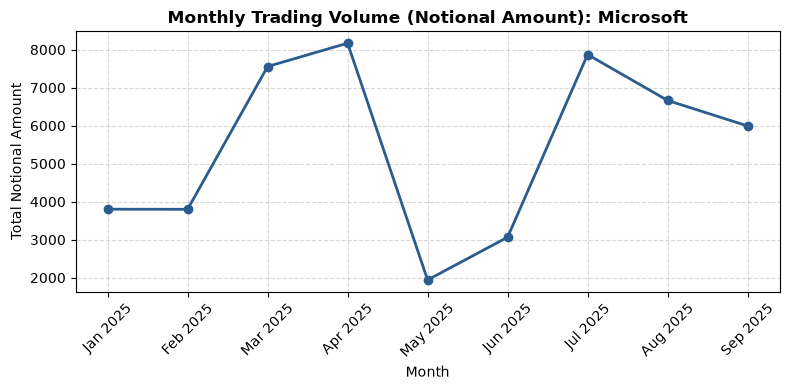

In [ ]:
# 5. Answer to Questions (part 3 - line chart)
# #########################################################################

# Identify most frequent instrument type
top_inst = q2_df["Instrument"].mode()[0]
display(Markdown(f"**Most Frequently Traded Instrument:** {top_inst}"))

# Calculate monthly volume (Notional Amount)
monthly_vol = (
    q2_df[q2_df["Instrument"] == top_inst]
    .groupby(q2_df["Trade Date"].dt.to_period("M"))["Notional Amount"]
    .sum()
)

# Plot trading volume over time
plt.figure(figsize=(8, 4))
plt.plot(monthly_vol.index.strftime("%b %Y"), monthly_vol, marker="o", color="#2b5c8f", linewidth=2)
plt.title(f"Monthly Trading Volume (Notional Amount): {top_inst}", fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Total Notional Amount")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# 6. Answer to Questions (part 5 - cumulative and annualised turnover)
# #########################################################################


# Cumulative Turnover (Gross Traded Value)
cum_turnover = q2_df["Settlement Amount"].sum()

# 2. Count distinct active trading days in your data
trading_days_count = q2_df["Trade Date"].nunique()

# 3. Annualize using the 252 business days convention
ann_turnover = cum_turnover * (252 / trading_days_count)

# Output results
print(f"Cumulative Turnover: ${cum_turnover:,.2f}")
print(f"Unique Trading Days: {trading_days_count}")
print(f"Annualized Turnover (Business Days): ${ann_turnover:,.2f}")

Cumulative Turnover: $22,262,089.00
Unique Trading Days: 145
Annualized Turnover (Business Days): $38,689,975.37
